In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [191]:
end_range = 1.0
start_range = -1.0
num_samples = 1000
test_samples = 1000
x = (end_range - start_range) * torch.rand(num_samples + test_samples, 2) + start_range
y = x[:, 0] * x[:, 1]

dataset = {
    'train_input': x[:1000].to(device),
    'train_label': y[:1000].unsqueeze(dim=1).to(device),
    'test_input': x[-test_samples:].to(device),
    'test_label': y[-test_samples:].unsqueeze(dim=1).to(device)
}

print(f"Train shape: {dataset['train_input'].shape}, {dataset['train_label'].shape}")
print(f"Test shape: {dataset['test_input'].shape}, {dataset['test_label'].shape}")

Train shape: torch.Size([1000, 2]), torch.Size([1000, 1])
Test shape: torch.Size([1000, 2]), torch.Size([1000, 1])


In [192]:
# Определение модели: маленькая полносвязная сеть
class TinyOpNet(nn.Module):
    def __init__(self, input_dim=2, hidden_dims=[4], output_dim=1):
        super().__init__()
        layers = []
        prev_dim = input_dim
        for h in hidden_dims:
            layers.append(nn.Linear(prev_dim, h))
            layers.append(nn.Tanh())  # можно попробовать Tanh или другие
            prev_dim = h
        layers.append(nn.Linear(prev_dim, output_dim))
        self.net = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.net(x)

In [211]:
model = TinyOpNet(input_dim=2, hidden_dims=[4], output_dim=1).to(device)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-1)

# Обучение
epochs = 1000
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(dataset['train_input'])
    loss = criterion(outputs, dataset['train_label'])
    loss.backward()
    optimizer.step()
    
    # Оценка на тесте
    model.eval()
    with torch.no_grad():
        test_outputs = model(dataset['test_input'])
        test_loss = criterion(test_outputs, dataset['test_label'])
    
    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Train Loss: {loss.item():.6f}, Test Loss: {test_loss.item():.6f}')

Epoch [10/1000], Train Loss: 0.095773, Test Loss: 0.104142
Epoch [20/1000], Train Loss: 0.043598, Test Loss: 0.038867
Epoch [30/1000], Train Loss: 0.018886, Test Loss: 0.019044
Epoch [40/1000], Train Loss: 0.007379, Test Loss: 0.010768
Epoch [50/1000], Train Loss: 0.006378, Test Loss: 0.007345
Epoch [60/1000], Train Loss: 0.005643, Test Loss: 0.006364
Epoch [70/1000], Train Loss: 0.004859, Test Loss: 0.005950
Epoch [80/1000], Train Loss: 0.004163, Test Loss: 0.004939
Epoch [90/1000], Train Loss: 0.003590, Test Loss: 0.004502
Epoch [100/1000], Train Loss: 0.003139, Test Loss: 0.003922
Epoch [110/1000], Train Loss: 0.002790, Test Loss: 0.003515
Epoch [120/1000], Train Loss: 0.002514, Test Loss: 0.003219
Epoch [130/1000], Train Loss: 0.003078, Test Loss: 0.004818
Epoch [140/1000], Train Loss: 0.003157, Test Loss: 0.002807
Epoch [150/1000], Train Loss: 0.002149, Test Loss: 0.002757
Epoch [160/1000], Train Loss: 0.001965, Test Loss: 0.002501
Epoch [170/1000], Train Loss: 0.001893, Test Loss

In [212]:
# Диапазон, соответствующий обучающим данным (например, [0.1, 1.0])
x_range = np.linspace(-1.0, 1.0, 50)
y_range = np.linspace(-1.0, 1.0, 50)

In [213]:
# Создаём сетку
X, Y = np.meshgrid(x_range, y_range)
grid_points = np.stack([X.ravel(), Y.ravel()], axis=1)
grid_tensor = torch.tensor(grid_points, dtype=torch.float32).to(device)

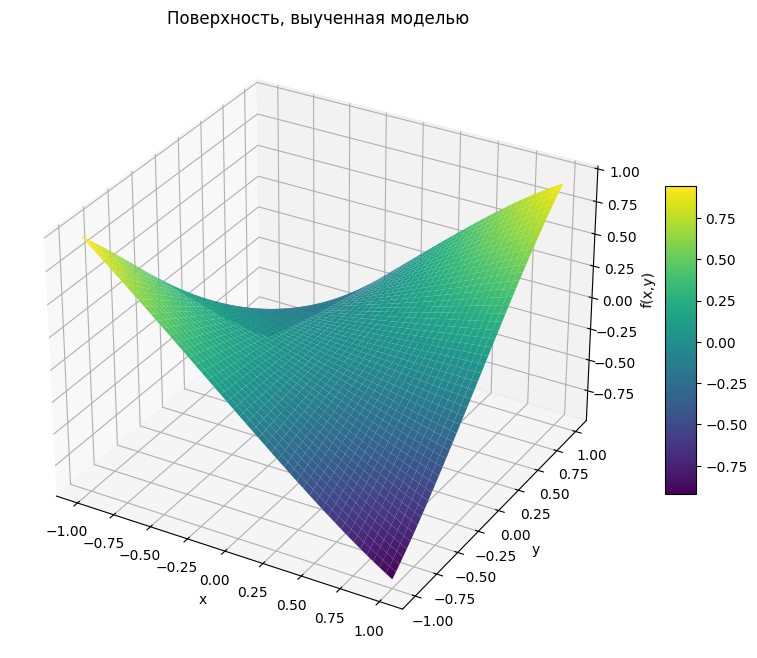

In [214]:
# Получаем предсказания модели
with torch.no_grad():
    Z_pred = model(grid_tensor).cpu().numpy().reshape(X.shape)

# Z_pred = X * Y

# Построение графика
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(X, Y, Z_pred, cmap='viridis', edgecolor='none')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('f(x,y)')
ax.set_title('Поверхность, выученная моделью')
fig.colorbar(surf, shrink=0.5, aspect=10)
plt.show()